In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import joblib


In [2]:
#Load Train / Val / Test
train_df = pd.read_csv("../data/processed/train.csv", encoding="utf-8")
val_df   = pd.read_csv("../data/processed/val.csv", encoding="utf-8")
test_df  = pd.read_csv("../data/processed/test.csv", encoding="utf-8")

train_df.head()


,Comment_clean,Label_id
0,thalaiva chance e illa thalaiva ovoru sean um...,0
1,marked my comment simbu pesrathu matum than pa...,1
2,title card bgm vara level nu soluravuga like pl,1
3,router එකේ ප්‍රශ්නයක් වෙන්න පුලුවන්.,0
4,kathi paththi pesura ellarukkum orey oru vidai...,1


In [3]:
#Define X and y
X_train = train_df["Comment_clean"]
y_train = train_df["Label_id"]

X_val = val_df["Comment_clean"]
y_val = val_df["Label_id"]

X_test = test_df["Comment_clean"]
y_test = test_df["Label_id"]


In [4]:
#TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    analyzer="word"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)


In [5]:
#Train Linear SVM
svm_model = LinearSVC(max_iter=2000)

svm_model.fit(X_train_tfidf, y_train)


,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [6]:
#Validation Results
y_val_pred = svm_model.predict(X_val_tfidf)

print("Validation Results (Linear SVM)")
print(classification_report(y_val, y_val_pred, target_names=["NON_HATE", "HATE"]))


Validation Results (Linear SVM)
              precision    recall  f1-score   support

    NON_HATE       0.88      0.93      0.90      5672
        HATE       0.64      0.49      0.55      1459

    accuracy                           0.84      7131
   macro avg       0.76      0.71      0.73      7131
weighted avg       0.83      0.84      0.83      7131



In [7]:
#Test Results
y_test_pred = svm_model.predict(X_test_tfidf)

print("Test Results (Linear SVM)")
print(classification_report(y_test, y_test_pred, target_names=["NON_HATE", "HATE"]))


Test Results (Linear SVM)
              precision    recall  f1-score   support

    NON_HATE       0.88      0.93      0.91      5673
        HATE       0.66      0.50      0.57      1458

    accuracy                           0.85      7131
   macro avg       0.77      0.72      0.74      7131
weighted avg       0.83      0.85      0.84      7131



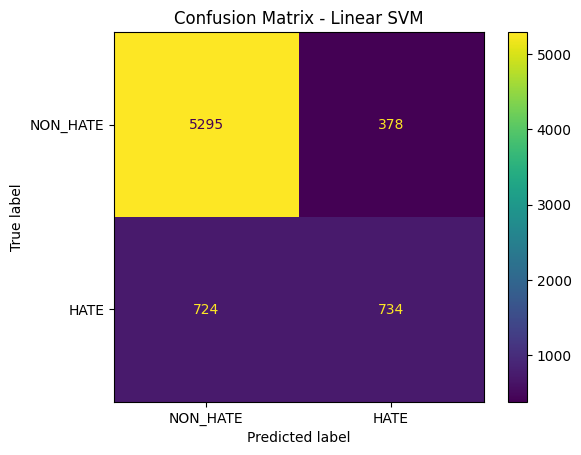

In [8]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NON_HATE", "HATE"]
)

disp.plot()
plt.title("Confusion Matrix - Linear SVM")
plt.show()


In [9]:
#Save Model
joblib.dump(svm_model, "../models/svm_linear.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")


['../models/tfidf_vectorizer.pkl']

In [10]:
#Train Balanced SVM
svm_balanced = LinearSVC(
    class_weight="balanced",
    max_iter=2000
)

svm_balanced.fit(X_train_tfidf, y_train)


,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

In [11]:
#Evaluate Balanced Model
y_test_pred_bal = svm_balanced.predict(X_test_tfidf)

print("Test Results (Balanced Linear SVM)")
print(classification_report(y_test, y_test_pred_bal, target_names=["NON_HATE", "HATE"]))


Test Results (Balanced Linear SVM)
              precision    recall  f1-score   support

    NON_HATE       0.91      0.84      0.87      5673
        HATE       0.51      0.67      0.58      1458

    accuracy                           0.80      7131
   macro avg       0.71      0.75      0.73      7131
weighted avg       0.83      0.80      0.81      7131



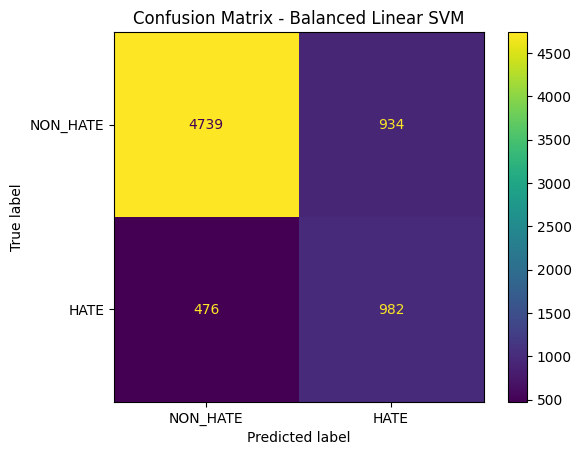

In [12]:
#Balanced Confusion Matrix
cm_bal = confusion_matrix(y_test, y_test_pred_bal)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bal,
    display_labels=["NON_HATE", "HATE"]
)

disp.plot()
plt.title("Confusion Matrix - Balanced Linear SVM")
plt.show()


In [13]:
#Save Balanced Model
joblib.dump(svm_balanced, "../models/svm_linear_balanced.pkl")


['../models/svm_linear_balanced.pkl']

In [14]:
# Linear SVM report
svm_report = classification_report(
    y_test,
    y_test_pred,
    target_names=["NON_HATE", "HATE"]
)

# Balanced SVM report
svm_bal_report = classification_report(
    y_test,
    y_test_pred_bal,
    target_names=["NON_HATE", "HATE"]
)

# Save to file
with open("../results/svm_results.txt", "w", encoding="utf-8") as f:
    f.write("=== Linear SVM ===\n\n")
    f.write(svm_report)
    
    f.write("\n\n=== Linear SVM (Balanced) ===\n\n")
    f.write(svm_bal_report)

print("SVM results saved successfully.")


SVM results saved successfully.
